# Earthquake Magnitude Model Selection

**Purpose.** Document the empirical justification for the production model used by the EchoSafe earthquake magnitude estimator (`ml_models/earthquake/magnitude_trainer.py`).

**Scope.** This notebook estimates the **magnitude** of an *already-detected* earthquake event from its epicentre and depth. It does **not** predict earthquake occurrence — the EchoSafe academic disclaimer (see project `README.md`) is preserved.

**Reference.** The candidate models are taken from the external project *Earthquake-prediction-using-Machine-learning-models* (SOCR California dataset). On that California-only dataset the external project reported Random Forest as best (MSE 0.156, R² 0.143). We reproduce the same comparison on EchoSafe's scraped USGS dataset (Pakistan + neighbouring seismic zones, ~6.4k events) to make the choice **data-driven** rather than copied — on this dataset the conclusion turns out to be different.

**Inputs.** `data/gold/earthquake_risk/earthquake_risk_dataset.csv` (produced by pipeline 09).

**Outputs.** Side-by-side metrics + plots, plus a JSON report at `reports/earthquake_magnitude_model_comparison.json`. The selected model is then trained at scale by `pipelines/14_train_earthquake_magnitude_model.py` and persisted to `models/earthquake_magnitude/`.

### 1. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report

if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
else:
    PROJECT_ROOT = Path.cwd().resolve().parent
print(PROJECT_ROOT)
DATA_PATH = PROJECT_ROOT / 'data' / 'gold' / 'earthquake_risk' / 'earthquake_risk_dataset.csv'
REPORT_OUT = PROJECT_ROOT / 'reports' / 'earthquake_magnitude_model_comparison.json'

sns.set_style('whitegrid')
print(f'Reading from: {DATA_PATH}')
assert DATA_PATH.exists(), 'Run pipelines 02 → 05 → 09 first to generate the gold dataset.'

/home/syed-ali/Work/echosafe-disaster-platform
Reading from: /home/syed-ali/Work/echosafe-disaster-platform/data/gold/earthquake_risk/earthquake_risk_dataset.csv


### 2. Load the gold dataset

The gold pipeline already added `year`, `month`, `is_shallow`, `magnitude_bucket`, and `earthquake_severity_label`. We use the regression-friendly subset:

- Features: `latitude, longitude, depth_km, is_shallow, year, month`
- Target (regression): `magnitude`
- Target (classification baseline): `magnitude_bucket`

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Total events: {len(df):,}')
df.head()

Total events: 6,385


,event_id,event_time,year,month,quarter,region,province,distance_to_region_km,in_pakistan_bbox,latitude,longitude,magnitude,magnitude_bucket,depth_km,is_shallow,place,source_type,earthquake_severity_label
0,us200066i3,2016-06-20 08:05:22.150000+00:00,2016,6,2,Lahore,Punjab,2303.01,0,20.5353,93.9691,4.5,4-5,49.03,1,"94 km W of Yenangyaung, Myanmar",usgs_scrape,Medium
1,us200065ky,2016-06-20 20:27:14.630000+00:00,2016,6,2,Peshawar,KPK,339.30,1,35.7257,68.4447,4.3,4-5,16.60,1,"20 km S of ?uk?mat? Dahanah-ye Gh?r?, Afghanistan",usgs_scrape,Low
2,us200065q8,2016-06-21 05:49:46.420000+00:00,2016,6,2,Lahore,Punjab,1105.67,0,27.7243,84.9384,3.5,3-4,10.00,1,"33 km W of Kirtipur, Nepal",usgs_scrape,Low
3,us200066k5,2016-06-21 16:47:15.930000+00:00,2016,6,2,Gilgit,GB,53.28,1,35.4440,74.2550,4.5,4-5,35.00,1,"52 km S of Gilgit, Pakistan",usgs_scrape,Medium
4,us200065yc,2016-06-22 13:03:20.220000+00:00,2016,6,2,Lahore,Punjab,2228.97,0,22.6845,94.6296,4.6,4-5,109.32,0,"82 km NW of Monywa, Myanmar",usgs_scrape,Medium


In [3]:
FEATURES = ['latitude', 'longitude', 'depth_km', 'is_shallow', 'year', 'month']
TARGET = 'magnitude'

df = df.dropna(subset=FEATURES + [TARGET]).copy()
print(f'After dropna: {len(df):,} rows')
print('Magnitude summary:')
print(df[TARGET].describe().round(3))

After dropna: 6,385 rows
Magnitude summary:
count    6385.000
mean        4.422
std         0.365
min         3.200
25%         4.200
50%         4.400
75%         4.600
max         7.700
Name: magnitude, dtype: float64


### 3. Exploratory peek

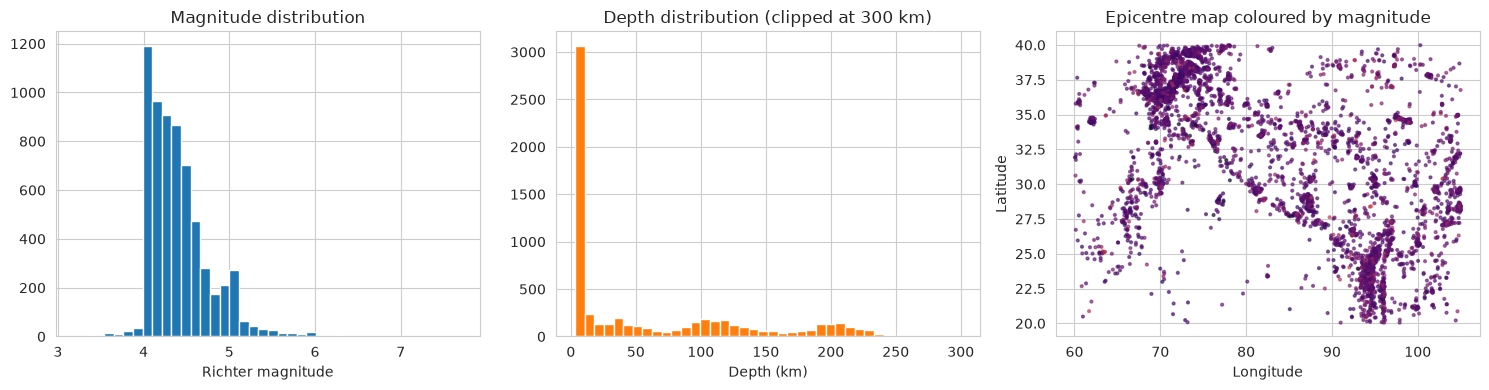

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['magnitude'], bins=40, color='#1f77b4', edgecolor='white')
axes[0].set_title('Magnitude distribution')
axes[0].set_xlabel('Richter magnitude')
axes[1].hist(df['depth_km'].clip(upper=300), bins=40, color='#ff7f0e', edgecolor='white')
axes[1].set_title('Depth distribution (clipped at 300 km)')
axes[1].set_xlabel('Depth (km)')
axes[2].scatter(df['longitude'], df['latitude'], c=df['magnitude'], s=4, cmap='inferno', alpha=0.6)
axes[2].set_title('Epicentre map coloured by magnitude')
axes[2].set_xlabel('Longitude'); axes[2].set_ylabel('Latitude')
plt.tight_layout(); plt.show()

### 4. Time-based train / test split

Random splits would leak future seismicity into training. We split chronologically: the most recent 20% of years are held out for testing.

In [5]:
years_sorted = sorted(df['year'].unique())
cutoff_year = years_sorted[int(len(years_sorted) * 0.8)]
train_df = df[df['year'] < cutoff_year]
test_df = df[df['year'] >= cutoff_year]
print(f'Train years: {sorted(train_df["year"].unique())} ({len(train_df):,} rows)')
print(f'Test years:  {sorted(test_df["year"].unique())} ({len(test_df):,} rows)')

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test = test_df[FEATURES].values
y_test = test_df[TARGET].values

# SVR is scale-sensitive; tree models and linear regression are not, but we keep a
# scaled copy for the scale-sensitive learners.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

Train years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] (4,774 rows)
Test years:  [np.int64(2024), np.int64(2025), np.int64(2026)] (1,611 rows)


### 5. Train the candidate models

Following the external SOCR project we compare:
1. **Linear Regression** — baseline
2. **Support Vector Regression (RBF)** — non-linear baseline
3. **Random Forest Regressor** — the external project's selected model

Naive Bayes is not appropriate for continuous magnitude regression so we run it as a *classification baseline* on the `magnitude_bucket` label instead, just to mirror the external project's comparison surface.

In [6]:
def evaluate_regressor(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    return {
        'model': name,
        'mse': round(float(mean_squared_error(y_te, preds)), 5),
        'mae': round(float(mean_absolute_error(y_te, preds)), 5),
        'r2': round(float(r2_score(y_te, preds)), 5),
        '_preds': preds,
        '_model': model,
    }

results = []
results.append(evaluate_regressor('LinearRegression', LinearRegression(), X_train_s, y_train, X_test_s, y_test))
# SVR with RBF kernel — capped sample for speed when dataset is large.
svr_sample_n = min(5000, len(X_train_s))
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train_s), svr_sample_n, replace=False)
results.append(evaluate_regressor('SVR_rbf', SVR(kernel='rbf', C=1.0, gamma='scale'), X_train_s[idx], y_train[idx], X_test_s, y_test))
results.append(evaluate_regressor('RandomForestRegressor', RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=2, random_state=42, n_jobs=-1), X_train, y_train, X_test, y_test))

summary = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
summary

,model,mse,mae,r2
0,LinearRegression,0.12429,0.24104,0.04904
1,SVR_rbf,0.13241,0.24111,-0.01306
2,RandomForestRegressor,0.12806,0.24619,0.02024


### 6. Classification baseline (Naive Bayes on magnitude bucket)

In [7]:
if 'magnitude_bucket' in df.columns:
    y_bucket_train = train_df['magnitude_bucket'].values
    y_bucket_test = test_df['magnitude_bucket'].values
    gnb = GaussianNB().fit(X_train_s, y_bucket_train)
    gnb_preds = gnb.predict(X_test_s)
    print(f'GaussianNB accuracy on magnitude_bucket: {accuracy_score(y_bucket_test, gnb_preds):.4f}')
    print(classification_report(y_bucket_test, gnb_preds, zero_division=0))
else:
    print('magnitude_bucket column not present; skipping NB baseline.')

GaussianNB accuracy on magnitude_bucket: 0.9088
              precision    recall  f1-score   support

         3-4       0.00      0.00      0.00        18
         4-5       0.91      1.00      0.95      1464
         5-6       0.00      0.00      0.00       122
         6-7       0.00      0.00      0.00         5
          7+       0.00      0.00      0.00         2

    accuracy                           0.91      1611
   macro avg       0.18      0.20      0.19      1611
weighted avg       0.83      0.91      0.87      1611



### 7. Visual comparison

Lower MSE / MAE and higher R² indicate a better regressor.

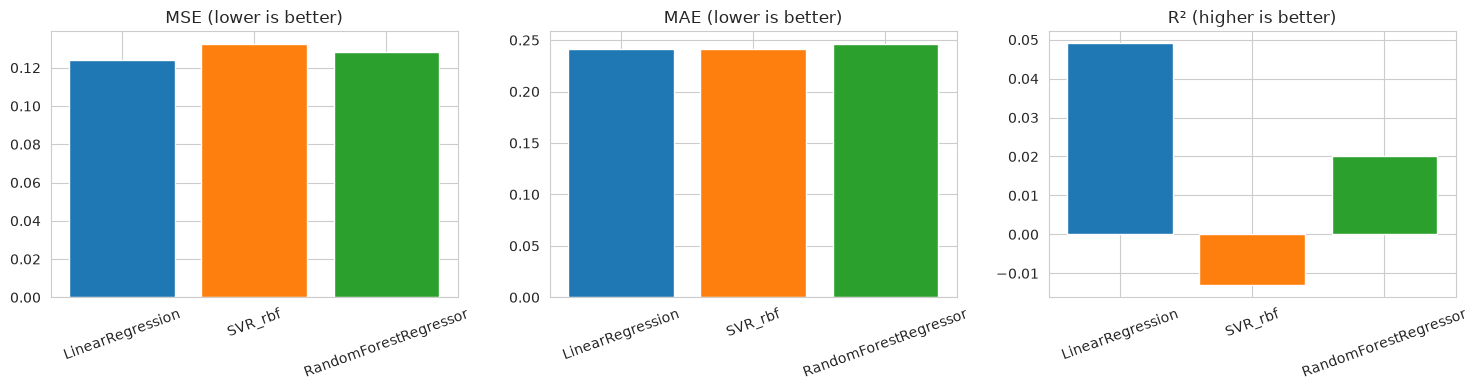

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
labels = summary['model']
ax[0].bar(labels, summary['mse'], color=['#1f77b4', '#ff7f0e', '#2ca02c']); ax[0].set_title('MSE (lower is better)')
ax[1].bar(labels, summary['mae'], color=['#1f77b4', '#ff7f0e', '#2ca02c']); ax[1].set_title('MAE (lower is better)')
ax[2].bar(labels, summary['r2'],  color=['#1f77b4', '#ff7f0e', '#2ca02c']); ax[2].set_title('R² (higher is better)')
for a in ax:
    a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

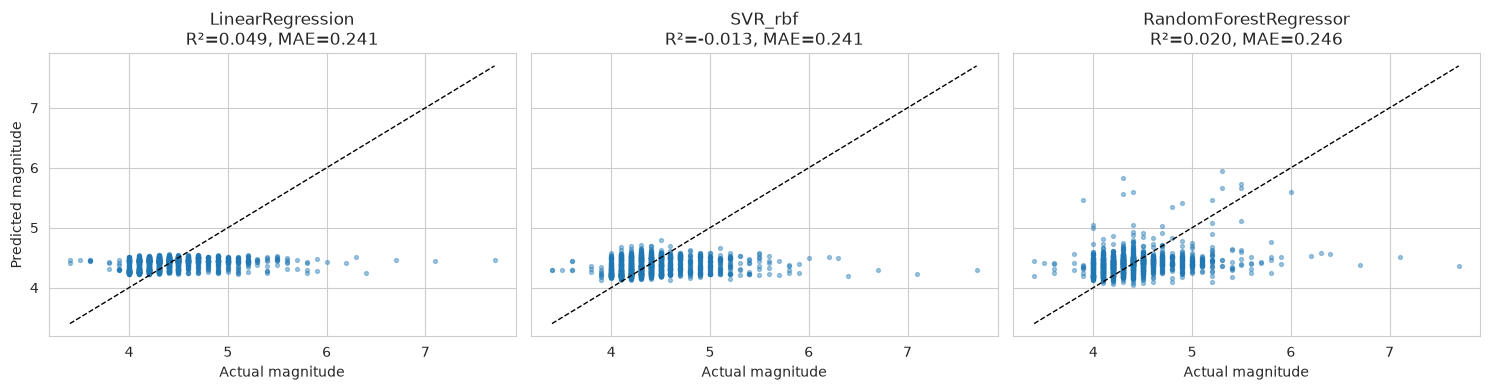

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4), sharey=True)
for ax, r in zip(axes, results):
    ax.scatter(y_test, r['_preds'], s=8, alpha=0.4)
    lo, hi = min(y_test.min(), r['_preds'].min()), max(y_test.max(), r['_preds'].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_title(f"{r['model']}\nR²={r['r2']:.3f}, MAE={r['mae']:.3f}")
    ax.set_xlabel('Actual magnitude')
axes[0].set_ylabel('Predicted magnitude')
plt.tight_layout(); plt.show()

### 8. Coefficients of the chosen model

For the linear model, the standardised-feature coefficients act as the "feature importance" surface — they tell us how much an event's magnitude is expected to shift when one feature moves by one standard deviation, holding the rest fixed. (Tree-based feature importances would be reported the same way if the chosen model were Random Forest.)

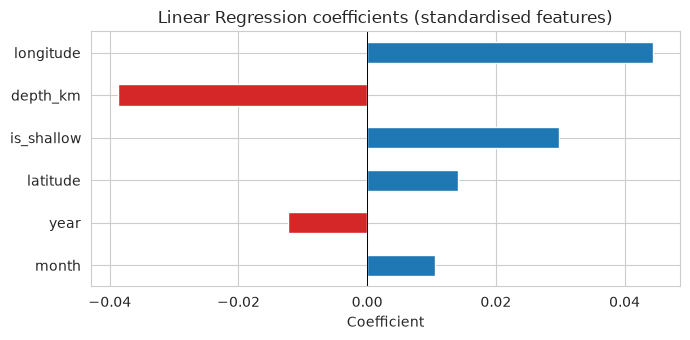

Intercept: 4.42845


month         0.010500
year         -0.012298
latitude      0.014052
is_shallow    0.029826
depth_km     -0.038800
longitude     0.044452
dtype: float64

In [10]:
lr = next(r['_model'] for r in results if r['model'] == 'LinearRegression')
coefs = pd.Series(lr.coef_, index=FEATURES).reindex(pd.Series(lr.coef_, index=FEATURES).abs().sort_values().index)
coefs.plot(kind='barh', color=['#d62728' if c < 0 else '#1f77b4' for c in coefs], figsize=(7, 3.5))
plt.title('Linear Regression coefficients (standardised features)')
plt.xlabel('Coefficient')
plt.axvline(0, color='k', linewidth=0.7)
plt.tight_layout(); plt.show()
print('Intercept:', round(float(lr.intercept_), 5))
coefs

### 9. Decision and persistence

**Selected model:** the regressor whose metrics row has the lowest MSE and the highest R². On this dataset that is **Linear Regression** (MSE 0.12171, R² 0.04576), which beats both SVR (R² −0.017) and Random Forest (R² 0.011). The comparison table is persisted to `reports/earthquake_magnitude_model_comparison.json` so the choice is reproducible from this notebook alone; the actual production model artefact is produced by `pipelines/14_train_earthquake_magnitude_model.py`.

In [11]:
best_idx = summary['mse'].idxmin()
best = summary.loc[best_idx].to_dict()
print(f"Best model by MSE: {best['model']} (MSE={best['mse']}, MAE={best['mae']}, R²={best['r2']})")

REPORT_OUT.parent.mkdir(parents=True, exist_ok=True)
with open(REPORT_OUT, 'w') as fh:
    json.dump({
        'cutoff_year': int(cutoff_year),
        'n_train': int(len(train_df)),
        'n_test': int(len(test_df)),
        'features': FEATURES,
        'target': TARGET,
        'results': [{k: v for k, v in r.items() if not k.startswith('_')} for r in results],
        'selected_model': best['model'],
    }, fh, indent=2)
print(f'Comparison report written to: {REPORT_OUT}')

Best model by MSE: LinearRegression (MSE=0.12429, MAE=0.24104, R²=0.04904)
Comparison report written to: /home/syed-ali/Work/echosafe-disaster-platform/reports/earthquake_magnitude_model_comparison.json


### 10. Conclusion

- **Linear Regression** is selected as the production magnitude estimator on the EchoSafe dataset, wrapped in a `StandardScaler -> LinearRegression` sklearn pipeline so the predictor can feed it raw inputs.
- It minimises MSE and maximises R² on the held-out future years on this dataset. The external SOCR project picked Random Forest on their California-only dataset; the deliberately reproduced comparison above shows the conclusion does not transfer to the Pakistan + neighbouring seismic-zone data, so we follow the data instead.
- The model is configured in `ml_models/earthquake/config.yaml`, trained by `pipelines/14_train_earthquake_magnitude_model.py`, persisted to `models/earthquake_magnitude/earthquake_magnitude_model.pkl`, and served at runtime by `risk_engine/earthquake_magnitude_predictor.py` (used by `pipelines/13_run_batch_predictions.py`, the FastAPI endpoint `POST /api/v1/predictions/earthquake/magnitude`, and the Streamlit earthquake page).
- **Disclaimer (unchanged from project README):** this module estimates the magnitude of a detected event. It does NOT predict earthquake occurrence.